In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_flame/fold0_0.5_summary.tsv", sep="\t")
fold0["fold"] = [0 for i in range(len(fold0))]

In [3]:
fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_flame/fold1_0.5_summary.tsv", sep="\t")
fold1["fold"] = [1 for i in range(len(fold1))]

In [4]:
fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_flame/fold2_0.5_summary.tsv", sep="\t")
fold2["fold"] = [2 for i in range(len(fold2))]

In [5]:
df = pd.concat([fold0, fold1, fold2], ignore_index=True)

In [6]:
len(df)

164

In [7]:
len(df[df["flame_result"] <= 0.0])

11

In [ ]:
df.columns

In [9]:
# filtering out unsuccessful optimizations
df = df[df["flame_result"] > 0.0]

In [10]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'SCD', 'flame_result',
       'flame_target', 'flame_init', 'num_edits', 'GC_seq', 'GC_slice',
       'GC_slice_edited', 'init_CTCFs_num', 'CTCFs_num', 'FIMO_sum',
       'FIMO_max', 'orientation', 'positions'],
      dtype='object')

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

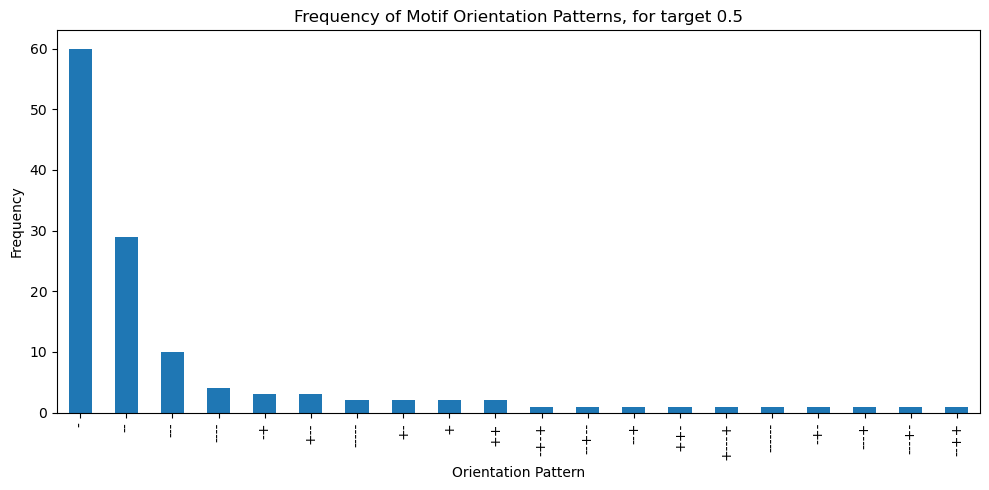

In [12]:
orientation_counts = df[df['orientation'] != "no"]['orientation'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns, for target 0.5")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [13]:
df_melted = df.melt(value_vars=['flame_init', 'flame_result'], var_name='Type', value_name='flame strength')

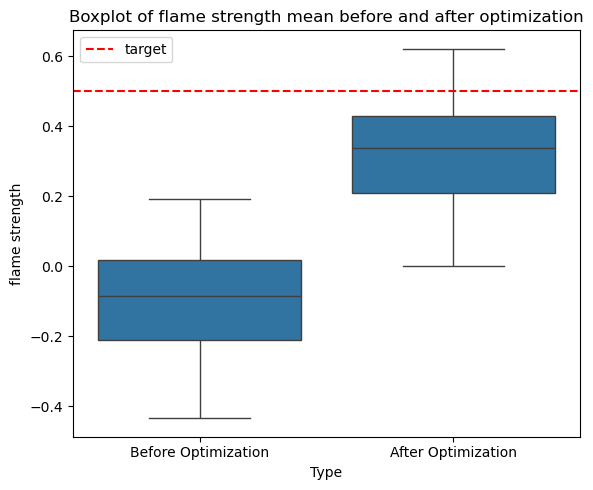

In [14]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Type', y='flame strength', data=df_melted)
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='target')
plt.xticks([0, 1], ['Before Optimization', 'After Optimization'])
plt.title('Boxplot of flame strength mean before and after optimization')
plt.legend()
plt.tight_layout()
plt.show()

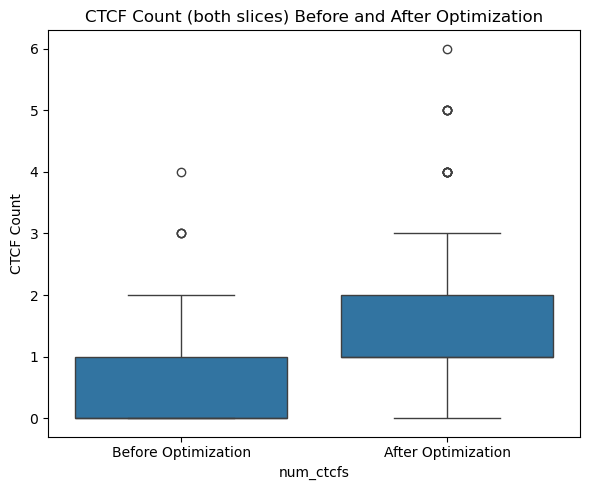

In [15]:
df_box_melted = df.melt(value_vars=['init_CTCFs_num', 'CTCFs_num'],
                            var_name='num_ctcfs', value_name='CTCF Count')

# Rename the categories for clarity
label_map = {
    'init_CTCFs_num': 'Before Optimization',
    'CTCFs_num': 'After Optimization'
}
df_box_melted['num_ctcfs'] = df_box_melted['num_ctcfs'].map(label_map)

# Plotting
plt.figure(figsize=(6, 5))
sns.boxplot(x='num_ctcfs', y='CTCF Count', data=df_box_melted)
plt.title('CTCF Count (both slices) Before and After Optimization')
plt.tight_layout()
plt.show()

In [16]:
from scipy.stats import pearsonr

In [17]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'SCD', 'flame_result',
       'flame_target', 'flame_init', 'num_edits', 'GC_seq', 'GC_slice',
       'GC_slice_edited', 'init_CTCFs_num', 'CTCFs_num', 'FIMO_sum',
       'FIMO_max', 'orientation', 'positions'],
      dtype='object')

In [18]:
# Calculate Pearson correlation coefficient
r_value, p_value = pearsonr(df['flame_target'], df['flame_result'])

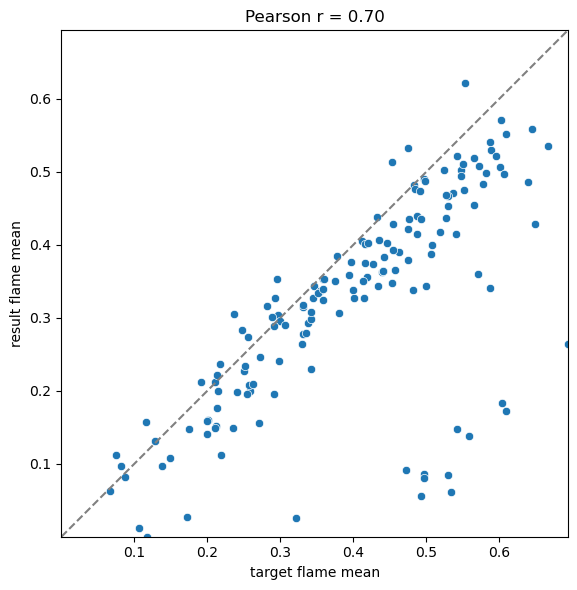

In [20]:
# Determine shared range for both axes
min_val = min(df['flame_target'].min(), df['flame_result'].min())
max_val = max(df['flame_target'].max(), df['flame_result'].max())

# Plotting the scatterplot with equal axis limits and square aspect ratio
plt.figure(figsize=(6, 6))
sns.scatterplot(x='flame_target', y='flame_result', data=df)
plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--')  # reference diagonal
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect('equal', adjustable='box')
plt.title(f'Pearson r = {r_value:.2f}')
plt.xlabel('target flame mean')
plt.ylabel('result flame mean')
plt.tight_layout()
plt.show()


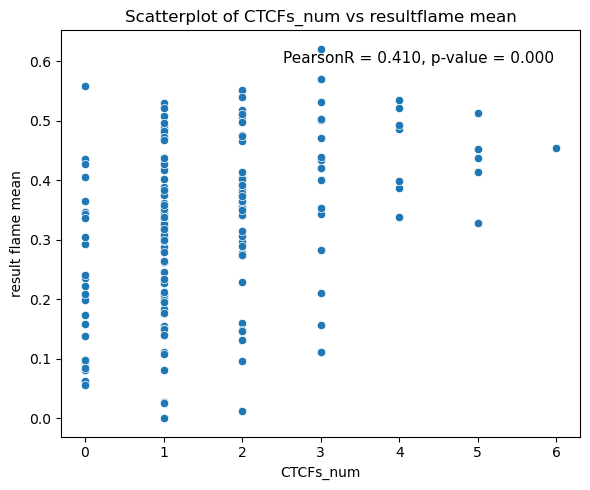

In [21]:

# Compute PearsonR and p-value
r, p = pearsonr(df['CTCFs_num'], df['flame_result'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='CTCFs_num', y='flame_result', data=df)

# Add labels and title
plt.xlabel('CTCFs_num')
plt.ylabel('result flame mean')
plt.title('Scatterplot of CTCFs_num vs resultflame mean')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

In [22]:
df["flame_diff"] = df["flame_result"] - df["flame_init"]

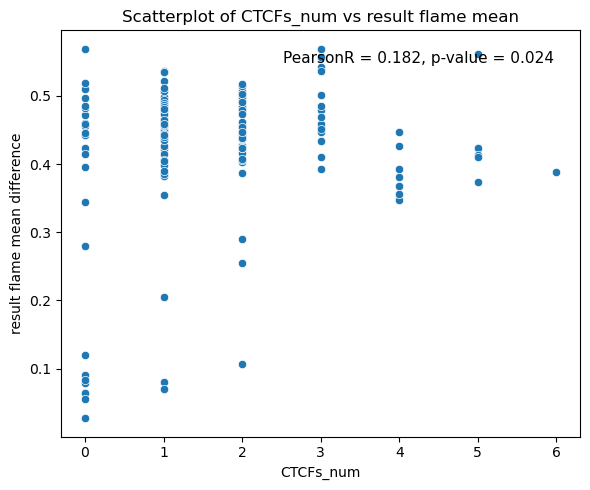

In [23]:
# Compute PearsonR and p-value
r, p = pearsonr(df['CTCFs_num'], df['flame_diff'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='CTCFs_num', y='flame_diff', data=df)

# Add labels and title
plt.xlabel('CTCFs_num')
plt.ylabel('result flame mean difference')
plt.title('Scatterplot of CTCFs_num vs result flame mean')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

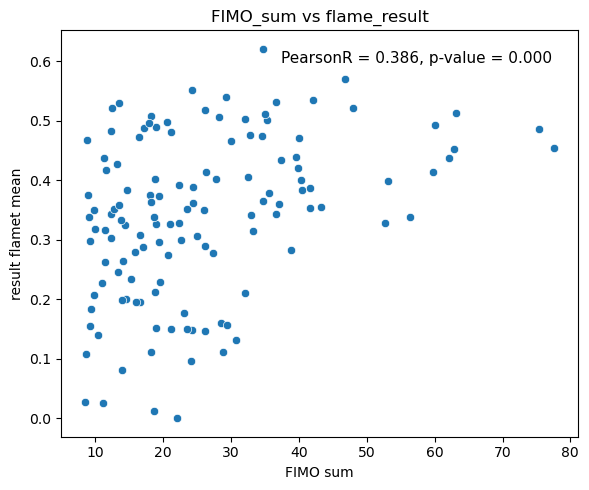

In [24]:
df_part = df[df["FIMO_sum"] > 0]

# Compute PearsonR and p-value
r, p = pearsonr(df_part['FIMO_sum'], df_part['flame_result'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_sum', y='flame_result', data=df_part)

# Add labels and title
plt.xlabel('FIMO sum')
plt.ylabel('result flamet mean')
plt.title('FIMO_sum vs flame_result')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

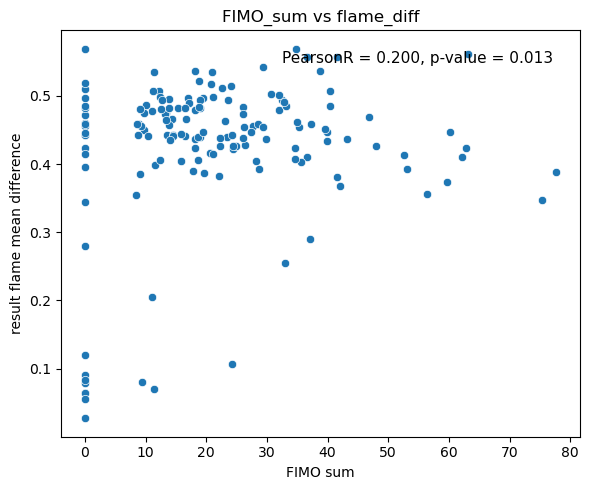

In [25]:
# df_part = df[df["FIMO_sum"] > 0]

# Compute PearsonR and p-value
r, p = pearsonr(df['FIMO_sum'], df['flame_diff'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_sum', y='flame_diff', data=df)

# Add labels and title
plt.xlabel('FIMO sum')
plt.ylabel('result flame mean difference')
plt.title('FIMO_sum vs flame_diff')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

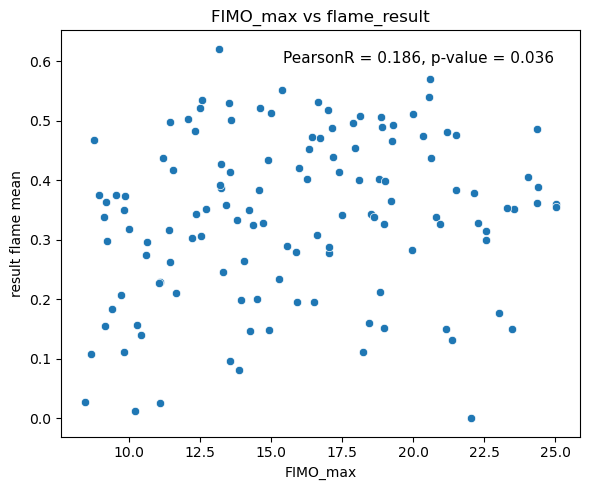

In [26]:
df_part = df[df["FIMO_max"] > 0]

# Compute PearsonR and p-value
r, p = pearsonr(df_part['FIMO_max'], df_part['flame_result'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_max', y='flame_result', data=df_part)

# Add labels and title
plt.xlabel('FIMO_max')
plt.ylabel('result flame mean')
plt.title('FIMO_max vs flame_result')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

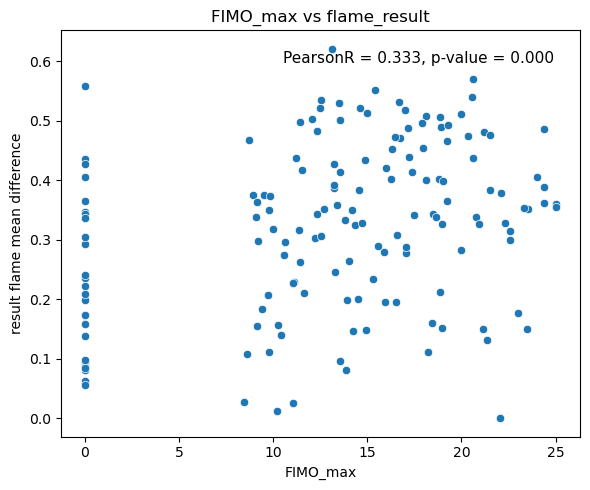

In [27]:
# Compute PearsonR and p-value
r, p = pearsonr(df['FIMO_max'], df['flame_diff'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_max', y='flame_result', data=df)

# Add labels and title
plt.xlabel('FIMO_max')
plt.ylabel('result flame mean difference')
plt.title('FIMO_max vs flame_result')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

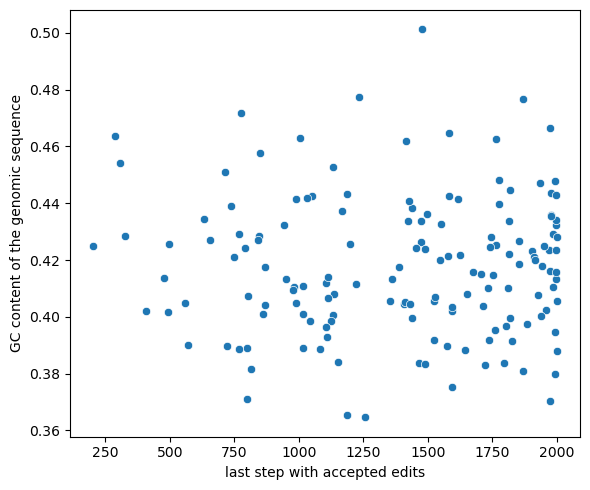

In [28]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='last_accepted_step',
    y='GC_seq',
    data=df
)
plt.xlabel('last step with accepted edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

In [29]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'SCD', 'flame_result',
       'flame_target', 'flame_init', 'num_edits', 'GC_seq', 'GC_slice',
       'GC_slice_edited', 'init_CTCFs_num', 'CTCFs_num', 'FIMO_sum',
       'FIMO_max', 'orientation', 'positions', 'flame_diff'],
      dtype='object')

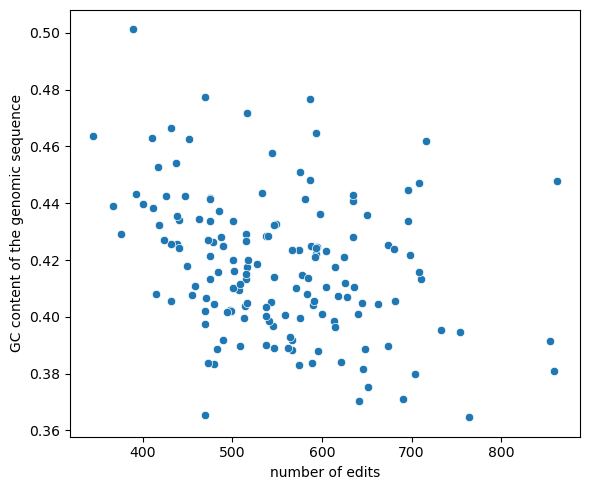

In [30]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='num_edits',
    y='GC_seq',
    data=df
)

plt.xlabel('number of edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

In [ ]:
df.columns

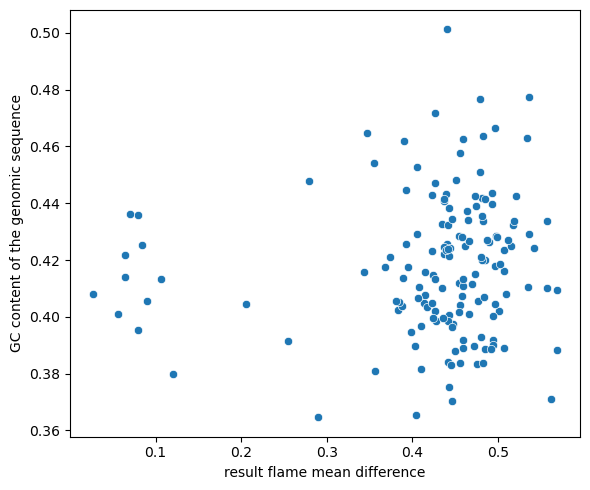

In [32]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='flame_diff',
    y='GC_seq',
    data=df
)

plt.xlabel('result flame mean difference')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

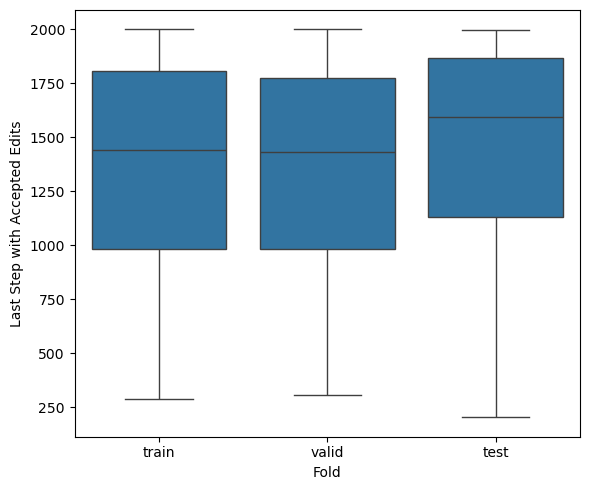

In [33]:
fold_map = {0: 'test', 1: 'valid', 2: 'train'}
df['set'] = df['fold'].map(fold_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='set', y='last_accepted_step', data=df, order=['train', 'valid', 'test'])
plt.xlabel('Fold')
plt.ylabel('Last Step with Accepted Edits')
plt.tight_layout()
plt.show()

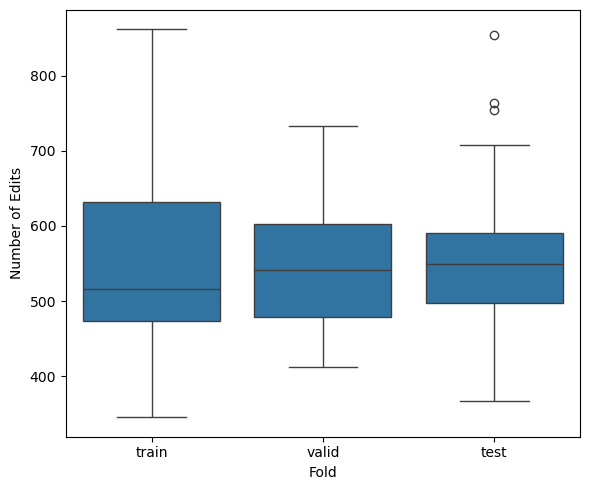

In [34]:
# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='set', y='num_edits', data=df, order=['train', 'valid', 'test'])
plt.xlabel('Fold')
plt.ylabel('Number of Edits')
plt.tight_layout()
plt.show()

In [35]:
from scipy.stats import ttest_rel

In [36]:
t_stat, p_val = ttest_rel(df['GC_slice'], df['GC_slice_edited'])

In [37]:
t_stat, p_val

(-13.352936625815502, 2.1124156903236435e-27)

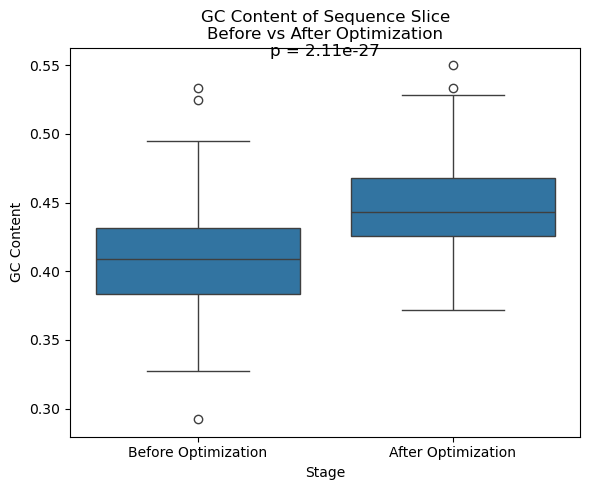

In [38]:
# Melt the DataFrame for plotting
df_gc_melted = df.melt(value_vars=['GC_slice', 'GC_slice_edited'],
                          var_name='Stage', value_name='GC Content')

# Rename the stages for clarity
stage_map = {
    'GC_slice': 'Before Optimization',
    'GC_slice_edited': 'After Optimization'
}
df_gc_melted['Stage'] = df_gc_melted['Stage'].map(stage_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Stage', y='GC Content', data=df_gc_melted)
plt.title('GC Content of Sequence Slice\nBefore vs After Optimization')
plt.text(0.5, max(df_gc_melted['GC Content']) + 0.005,
         f'p = {p_val:.3g}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()